# Loan Default Prediction System

## Objective
The objective of this project is to predict whether a loan applicant will default or repay the loan using machine learning classification models.

The model can help financial institutions reduce credit risk and automate loan approval decisions.

## Dataset Description
The dataset contains demographic and financial information of loan applicants.

Target Variable:
Loan_Status → Indicates whether the loan is repaid or defaulted.

Features include applicant income, loan amount, credit history, education, employment status and property area.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/loan_data_set.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Data Preprocessing
Steps performed:
- Removed irrelevant columns (Loan_ID)
- Handled missing values
- Encoded categorical variables
- Prepared features and target variable

In [3]:
df.drop("Loan_ID", axis=1, inplace=True)
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [4]:
# categorical → mode
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# numerical → median
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipython-input-3762038792.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipython-input-3762038792.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [5]:
df["Loan_Status"] = df["Loan_Status"].map({'Y':1, 'N':0})

In [6]:
df = pd.get_dummies(df, drop_first=True)
df

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,0,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,1,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,1,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,2900,0.0,71.0,360.0,1.0,1,False,False,False,False,False,False,False,False,False
610,4106,0.0,40.0,180.0,1.0,1,True,True,False,False,True,False,False,False,False
611,8072,240.0,253.0,360.0,1.0,1,True,True,True,False,False,False,False,False,True
612,7583,0.0,187.0,360.0,1.0,1,True,True,False,True,False,False,False,False,True


In [10]:
df.to_csv("/content/loan_data_cleaned.csv", index=False)

## Exploratory Data Analysis
EDA is performed to understand relationships between applicant attributes and loan default behaviour.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/loan_data_cleaned.csv")
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,0,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,1,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,1,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True


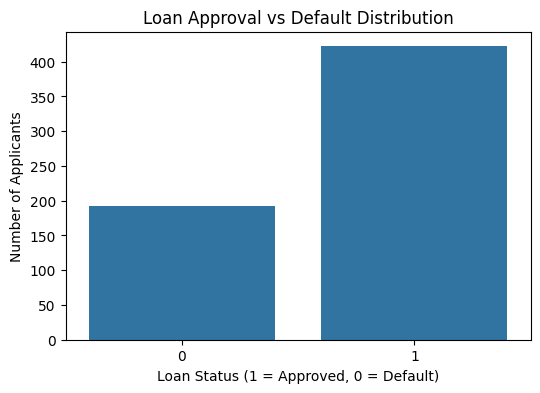

Loan_Status
1    0.687296
0    0.312704
Name: proportion, dtype: float64


In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval vs Default Distribution")
plt.xlabel("Loan Status (1 = Approved, 0 = Default)")
plt.ylabel("Number of Applicants")
plt.savefig("/content//target_distribution.png")
plt.show()

print(df['Loan_Status'].value_counts(normalize=True))

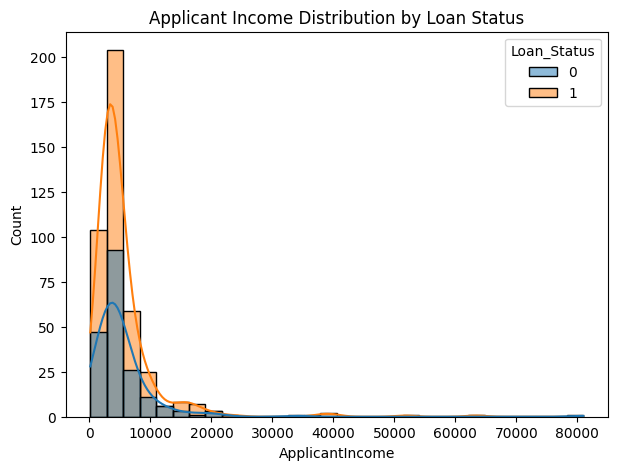

In [15]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x="ApplicantIncome", hue="Loan_Status", bins=30, kde=True)
plt.title("Applicant Income Distribution by Loan Status")
plt.savefig("/content/income_vs_status.png")
plt.show()

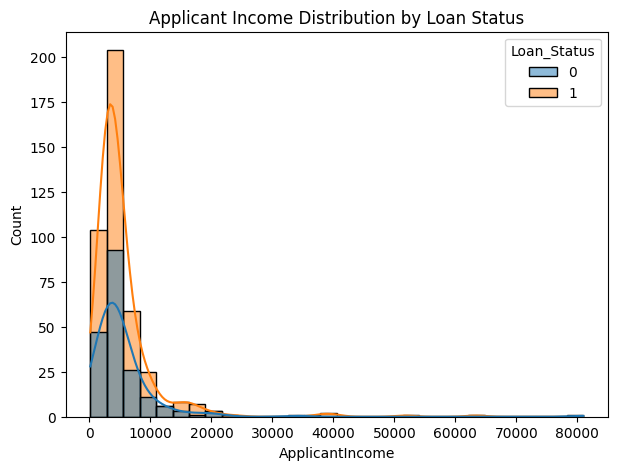

In [16]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x="ApplicantIncome", hue="Loan_Status", bins=30, kde=True)
plt.title("Applicant Income Distribution by Loan Status")
plt.savefig("/content/income_vs_status.png")
plt.show()

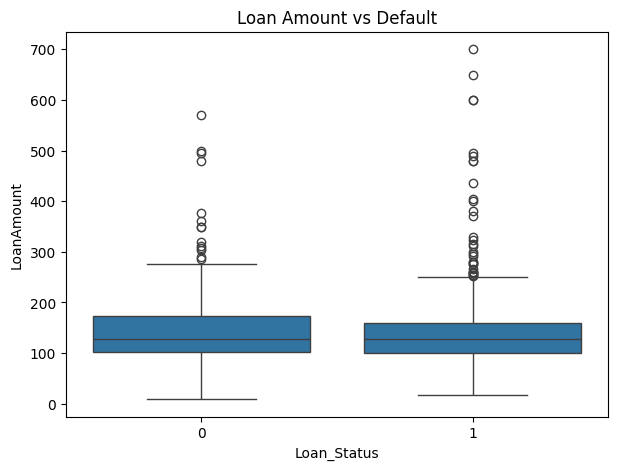

In [17]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Loan_Status", y="LoanAmount", data=df)
plt.title("Loan Amount vs Default")
plt.savefig("/content/loanamount_vs_status.png")
plt.show()

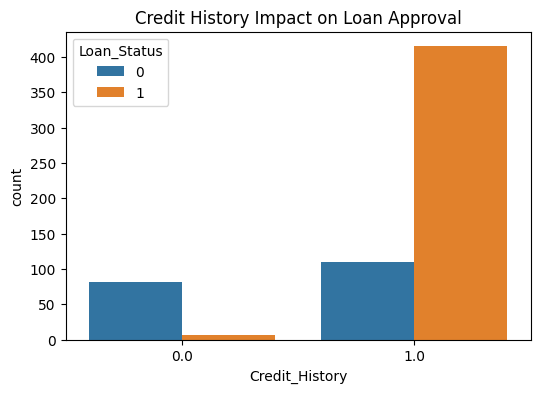

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History Impact on Loan Approval")
plt.savefig("/content/credit_history.png")
plt.show()

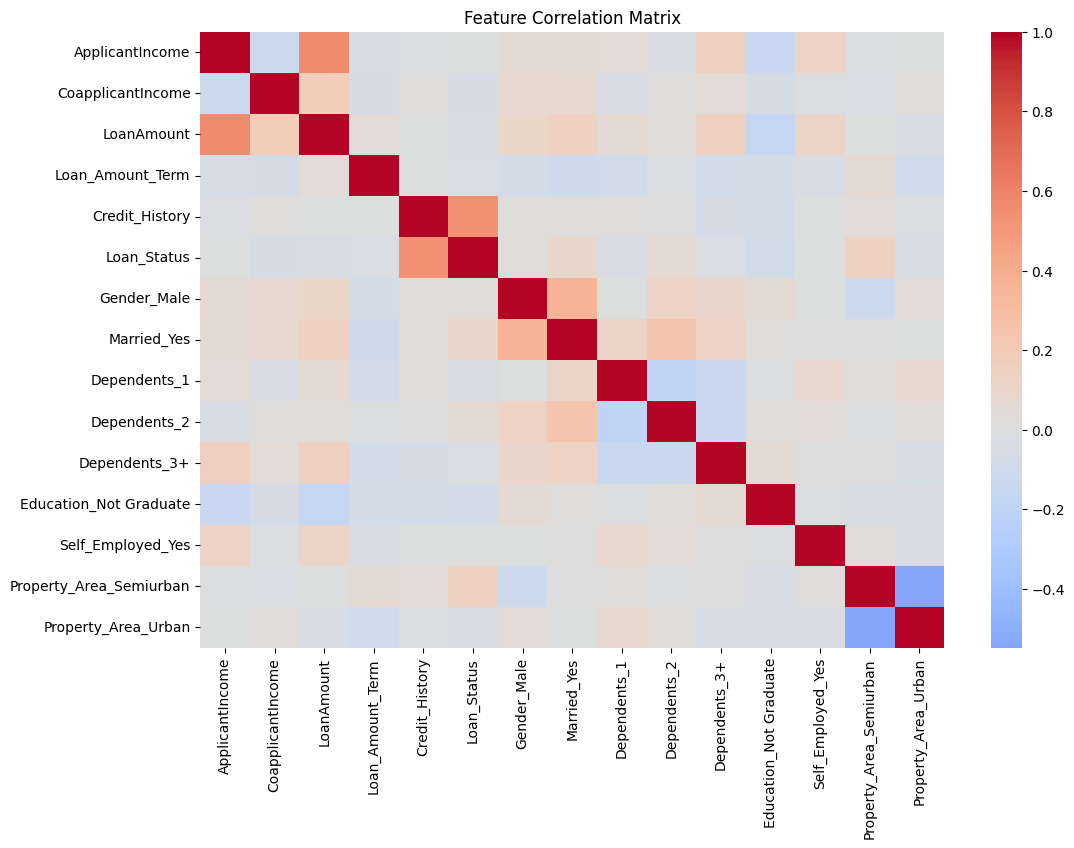

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.savefig("/content/correlation_heatmap.png")
plt.show()

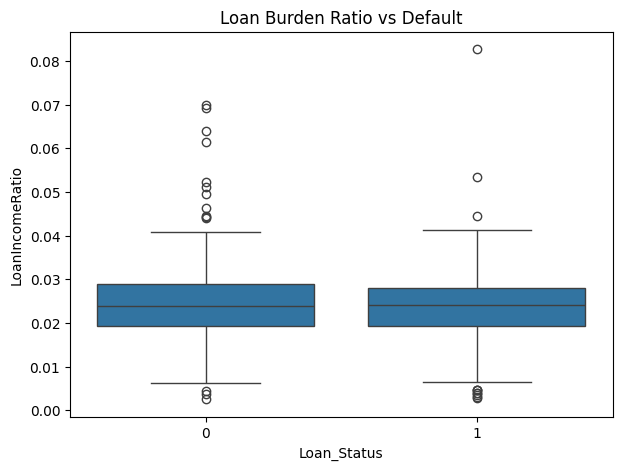

In [20]:
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
df["LoanIncomeRatio"] = df["LoanAmount"] / df["TotalIncome"]

plt.figure(figsize=(7,5))
sns.boxplot(x="Loan_Status", y="LoanIncomeRatio", data=df)
plt.title("Loan Burden Ratio vs Default")
plt.savefig("/content/loan_income_ratio.png")
plt.show()

### Observations
- Applicants with credit history = 1 have much higher approval chances
- Higher income applicants show lower default risk
- Loan amount impacts approval probability

In [22]:
df.to_csv("/content/loan_featured.csv", index=False)

## Model Training
Dataset split into training and testing sets (80-20).
Three classification algorithms were evaluated:
- Logistic Regression
- Decision Tree
- Random Forest

In [24]:
df = pd.read_csv("/content/loan_featured.csv")
df

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [25]:
df

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,TotalIncome,LoanIncomeRatio
0,5849,0.0,128.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True,5849.0,0.021884
1,4583,1508.0,128.0,360.0,1.0,0,True,True,True,False,False,False,False,False,False,6091.0,0.021015
2,3000,0.0,66.0,360.0,1.0,1,True,True,False,False,False,False,True,False,True,3000.0,0.022000
3,2583,2358.0,120.0,360.0,1.0,1,True,True,False,False,False,True,False,False,True,4941.0,0.024287
4,6000,0.0,141.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True,6000.0,0.023500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,2900,0.0,71.0,360.0,1.0,1,False,False,False,False,False,False,False,False,False,2900.0,0.024483
610,4106,0.0,40.0,180.0,1.0,1,True,True,False,False,True,False,False,False,False,4106.0,0.009742
611,8072,240.0,253.0,360.0,1.0,1,True,True,True,False,False,False,False,False,True,8312.0,0.030438
612,7583,0.0,187.0,360.0,1.0,1,True,True,False,True,False,False,False,False,True,7583.0,0.024660


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [29]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

## Model Evaluation Metrics
Models are evaluated using:
Accuracy, Precision, Recall, F1 Score and ROC-AUC

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

In [32]:
evaluate_model(y_test, y_pred_log, "Logistic Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest")


Logistic Regression
Accuracy: 0.8617886178861789
Precision: 0.84
Recall: 0.9882352941176471
F1 Score: 0.9081081081081082

Decision Tree
Accuracy: 0.7479674796747967
Precision: 0.8552631578947368
Recall: 0.7647058823529411
F1 Score: 0.8074534161490683

Random Forest
Accuracy: 0.8943089430894309
Precision: 0.9
Recall: 0.9529411764705882
F1 Score: 0.9257142857142857


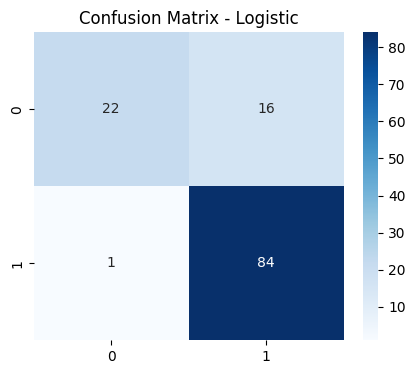

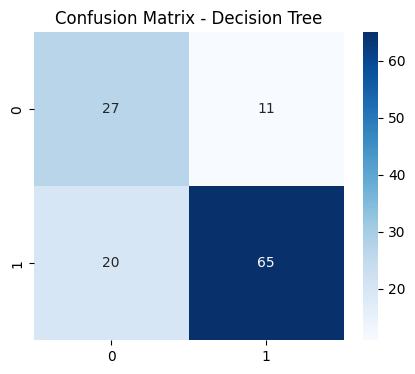

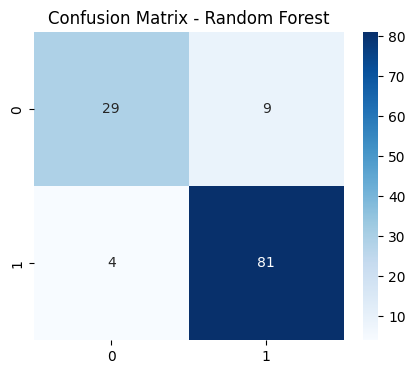

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

models = {
    "Logistic": y_pred_log,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

for name, pred in models.items():
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.savefig(f"/content/confusion_{name}.png")
    plt.show()

### Interpretation
Random Forest achieved the best performance and balanced false approvals and missed defaulters.
Decision Tree showed overfitting behaviour.
Logistic Regression performed well but missed complex relationships.

## Hyperparameter Tuning
Random Forest parameters were optimized using GridSearchCV to improve generalization and avoid overfitting.

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    params,
                    cv=5,
                    scoring="f1",
                    n_jobs=-1)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


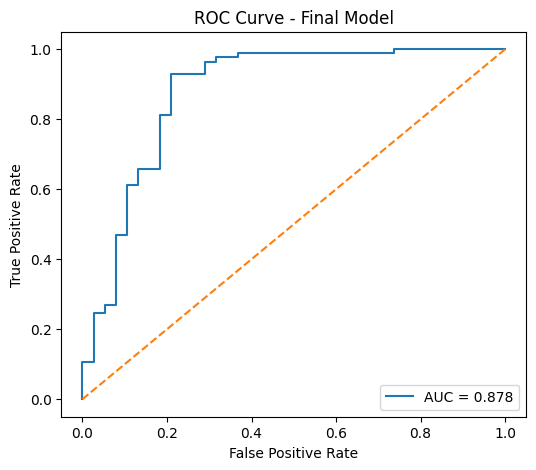

In [36]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.savefig("/content/roc_curve.png")
plt.show()

The ROC curve shows strong classification capability with AUC ≈ 0.878, indicating reliable ranking between defaulters and non-defaulters.

In [39]:
import joblib

joblib.dump(best_model, "/content/loan_default_model.pkl")

['/content/loan_default_model.pkl']

## Final Conclusion

Random Forest was selected as the final model due to highest predictive performance.

Key Findings:
- Credit history is the most important predictor
- Income and loan amount significantly influence default risk
- Controlled tree depth improves generalization

The model can be used as a decision-support tool in loan approval systems to reduce financial risk.